**What is polynomial regression?**

Polynomial regression is a form of Linear regression where only due to the ***Non-linear relationship between dependent and independent variables***, we add some polynomial terms to linear regression to convert it into Polynomial regression.

* In polynomial regression, the relationship between the dependent variable and the independent variable is modeled as an nth-degree polynomial function.

* Consider an example my input value is 35, and the degree of a polynomial is 2, so I will find 35 power 0, 35 power 1, and 35 power 2 this helps to interpret the non-linear relationship in data. The degree of order which to use is a Hyperparameter.





---



***Exampe No. 1 on polynomial regression***

**Step 1**: Import all the libraries

In [125]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score,mean_squared_error

**Step 1**: Create an array of data and plot the x,y values

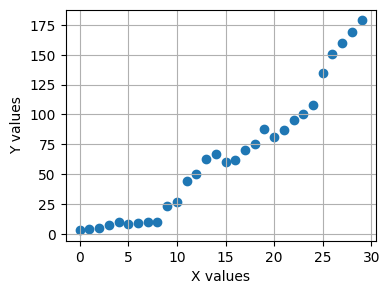

In [126]:
x=np.arange(0,30)
y=[3, 4, 5, 7, 10, 8, 9, 10, 10, 23, 27, 44, 50, 63, 67, 60, 62, 70, 75, 88, 81, 87, 95, 100, 108, 135, 151, 160, 169, 179]

# Plot data
plt.figure(figsize=(4,3))
plt.scatter(x,y)
plt.xlabel('X values')
plt.ylabel('Y values')
plt.grid(True)
plt.show()

**Step 3**: Split data in the train and test set

In [127]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

**Step 4**: Apply polynomial regression

convert the input to polynomial terms by using the degree as 2 for example.

In [128]:
#applying polynomial regression degree 2
poly=PolynomialFeatures(degree=2,include_bias=False)

poly_features_xtrain=poly.fit_transform(x_train.reshape(-1,1))     #x.reshape(-1,1) converts our 1D Numpy array to a 2D array.
poly_features_xtest=poly.fit_transform(x_test.reshape(-1,1))

# apply and fit the linear regression model
poly_reg_model=LinearRegression()
poly_reg_model.fit(poly_features_xtrain,y_train)
poly_reg_model.fit(poly_features_xtest,y_test)


LinearRegression()

In [129]:
# Get the intercept (b0) and coefficients (bi) from the trained model
intercept = poly_reg_model.intercept_
coefficients = poly_reg_model.coef_

print(intercept)
print(coefficients)


2.80590716297759
[0.73448585 0.17685637]


**Step 5**: start the prediction model and get the MSE

In [130]:
# start_predicting for Training set
import pandas as pd

poly_y_predict=poly_reg_model.predict(poly_features_xtrain)

data=pd.DataFrame({
  'Training_Values': y_train,
  'Predicting_Values':poly_y_predict

})
data.head()

,Training_Values,Predicting_Values
0,3,2.805907
1,10,8.573552
2,62,59.832911
3,8,10.899746
4,63,42.242950


In [131]:
# start_predicting for Testing set
import pandas as pd

poly_y_predict_test=poly_reg_model.predict(poly_features_xtest)

data=pd.DataFrame({
  'Testing_Values': y_test,
  'Predicting_Values':poly_y_predict_test

})

data.head()

,Testing_Values,Predicting_Values
0,160,151.565319
1,60,53.615878
2,100,113.256101
3,70,66.403658
4,10,20.000602


**Step 6**: plot the model

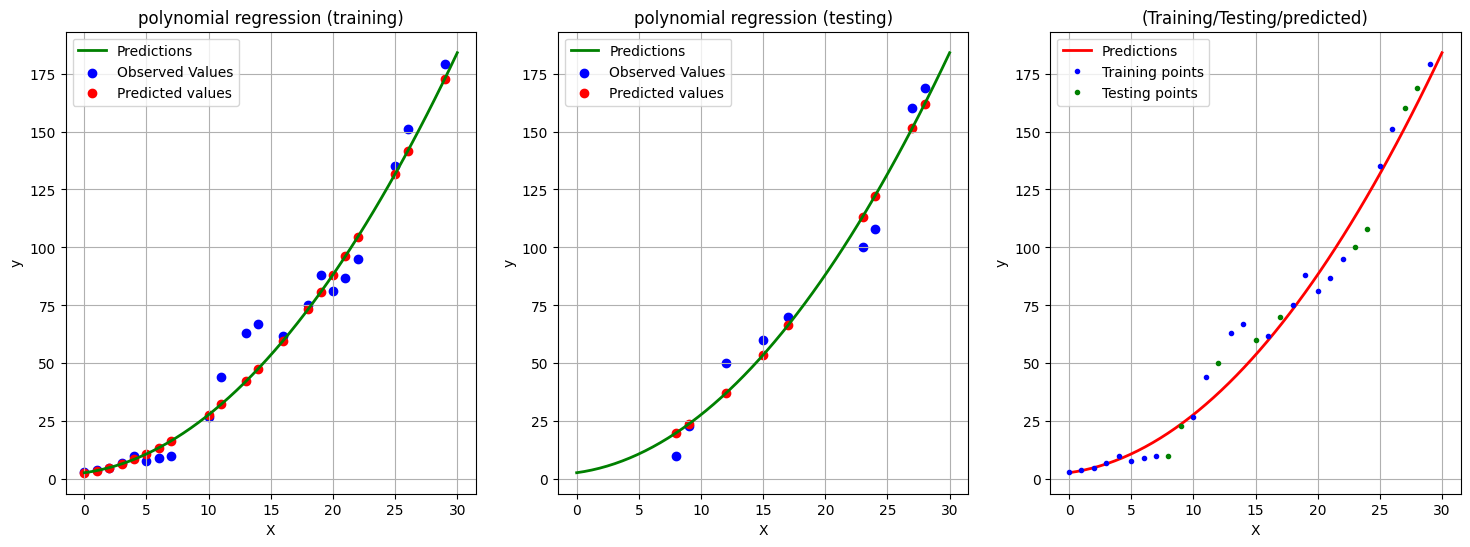

In [132]:
# plot model for training and testing

plt.figure(figsize=(18, 6))

X_new = np.linspace(0, 30).reshape(-1, 1)     #linespace(start,stop)
X_new_poly = poly.transform(X_new)
y_new = poly_reg_model.predict(X_new_poly)    #for training
y_new_test=poly_reg_model.predict(X_new_poly) #for testing


# Subplot 1
plt.subplot(1, 3, 1)
plt.title("polynomial regression (training)",size=12)
plt.plot(X_new,y_new, "g-", linewidth=2, label="Predictions")
plt.scatter(x_train,y_train, color='blue',label='Observed Values')
plt.scatter(x_train,poly_y_predict,c="red", label='Predicted values')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)


# Subplot 2
plt.subplot(1, 3, 2)
plt.title("polynomial regression (testing)",size=12)
plt.plot(X_new,y_new, "g-", linewidth=2, label="Predictions")
plt.scatter(x_test,y_test, color='blue',label='Observed Values')
plt.scatter(x_test,poly_y_predict_test,c="red", label='Predicted values')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)

# Subplot 3
plt.subplot(1, 3, 3)
plt.title("(Training/Testing/predicted)",size=12)
plt.plot(X_new,y_new, "r-", linewidth=2, label="Predictions")
plt.plot(x_train, y_train, "b.",label='Training points')
plt.plot(x_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)


plt.show()



In [133]:
length_of_y_train = len(y_train)
No_train = np.arange(1, length_of_y_train + 1) # generates an array that starts from 1 and ends at the length of y_train

sdf_train = pd.DataFrame({
    'No': No_train,
    'X': x_train,
    'Actual_y': y_train,
    'Predicted_y': poly_y_predict
})
print(sdf_train.head())

   No   X  Actual_y  Predicted_y
0   1   0         3     2.805907
1   2   4        10     8.573552
2   3  16        62    59.832911
3   4   5         8    10.899746
4   5  13        63    42.242950


In [134]:
length_of_y_test = len(y_test)
No_test = np.arange(1, length_of_y_test + 1) # generates an array that starts from 1 and ends at the length of y_train
sdf_test = pd.DataFrame({
    'No': No_test,
    'X': x_test,
    'Actual_y': y_test,
    'Predicted_y': poly_y_predict_test
})
print(sdf_test.head())

   No   X  Actual_y  Predicted_y
0   1  27       160   151.565319
1   2  15        60    53.615878
2   3  23       100   113.256101
3   4  17        70    66.403658
4   5   8        10    20.000602


**Step 5**: Calculate the RMSE

In [135]:
poly_rmse_train=np.sqrt(mean_squared_error(y_train,poly_y_predict))
print(f"poly rmse (training) = {poly_rmse_train}")

poly_rmse_test=np.sqrt(mean_squared_error(y_test,poly_y_predict_test))
print(f"poly rmse (testing) = {poly_rmse_test}")


poly rmse (training) = 8.296927078786407
poly rmse (testing) = 9.551382577798368


In [138]:
# Calculate metrics for training set
mse_train = mean_squared_error(y_train, poly_y_predict)
mae_train = mean_absolute_error(y_train, poly_y_predict)
r2_train = r2_score(y_train, poly_y_predict)

# Calculate metrics for testing set
mse_test = mean_squared_error(y_test, poly_y_predict_test)
mae_test = mean_absolute_error(y_test, poly_y_predict_test)
r2_test = r2_score(y_test, poly_y_predict_test)

In [139]:
# Create a DataFrame to store the metrics
metrics_df = pd.DataFrame({
    'Metric': ['MSE', 'MAE', 'R2_score','MSE', 'MAE','R2_score'],
    'Dataset': ['Train', 'Train', 'Train','Test','Test', 'Test'],
    'Value': [mse_train, mae_train, r2_train,mse_test, mae_test,r2_test]
})

metrics_df.T

,0,1,2,3,4,5
Metric,MSE,MAE,R2_score,MSE,MAE,R2_score
Dataset,Train,Train,Train,Test,Test,Test
Value,68.838999,5.963018,0.973851,91.228909,8.511375,0.967097


**Step 6**: predicting a new result with Polynomial Regression

In [140]:
poly_reg_model.predict(poly.fit_transform([[20]]))

array([88.23817219])



---



***Exampe No. 2 on polynomial regression***

In [142]:
# Import all the libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

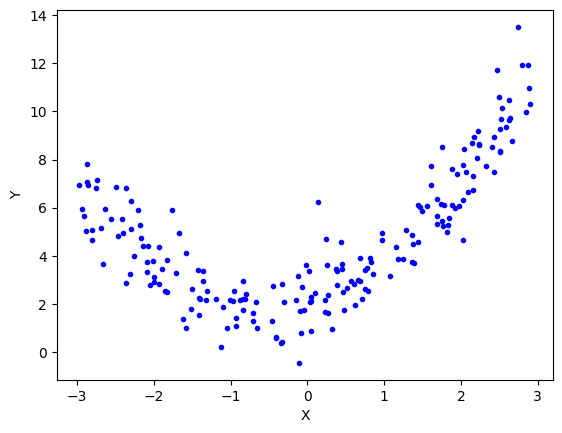

In [143]:
# Create and visualize the data
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9*X + 2 + np.random.randn(200, 1)
#equation used -> y = 0.8x^2 + 0.9x + 2
#visualize the data
plt.plot(X, y, 'b.')
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [146]:
# Split data in the train and test set
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [147]:
# Apply simple linear regression
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)
print(r2_score(y_test, y_pred))

0.05286007737989795


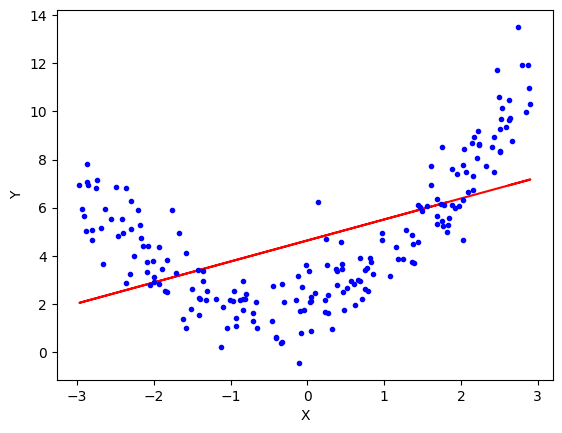

In [148]:
# Plot the simple LR
plt.plot(x_train, lr.predict(x_train), color="r")
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()


In [149]:
# Applying polynomial regression degree 2
poly = PolynomialFeatures(degree=2, include_bias=True)
x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)
#include bias parameter
lr = LinearRegression()
lr.fit(x_train_trans, y_train)
y_pred = lr.predict(x_test_trans)
print(r2_score(y_test, y_pred))

0.8292271172557579


In [150]:
# Get the b0 and coeffi_
print(lr.coef_)
print(lr.intercept_)

[[0.         0.86010809 0.8225339 ]]
[2.09457268]


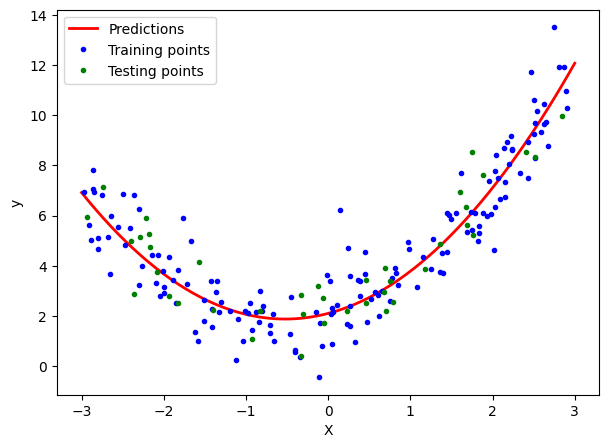

In [153]:
# Plot the model
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

plt.figure(figsize=(7,5))
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(x_train, y_train, "b.",label='Training points')
plt.plot(x_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()



---

**Good Luck. You can practice more :)**